# **La matrice de confusion (*Confusion Matrix* )**

C'est le point de départ de toute évaluation. Elle compare les prédictions du modèle à la réalité.

* Vrais Positifs *(True Positives - TP)* : Le modèle a prédit "Positif" et c'est "Positif".

* Vrais Négatifs *(True Negatives - TN)* : Le modèle a prédit "Négatif" et c'est "Négatif".

* Faux Positifs *(False Positives - FP)* : Erreur de Type I. Le modèle a prédit "Positif" alors que c'est "Négatif" (Alarme inutile).

* Faux Négatifs *(False Negatives - FN)* : Erreur de Type II. Le modèle a prédit "Négatif" alors que c'est "Positif" (Danger ! On a raté un cas réel).

# **Les Métriques de Base (*Basic Metrics*)**

**A. Justesse (Accuracy)**

* Définition : Le pourcentage global de bonnes réponses.

* Attention : À éviter si les classes sont déséquilibrées (Imbalanced Datasets).

$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$


**B. Précision (Precision)**

* Définition : Sur toutes les fois où le modèle a prédit "Positif", combien de fois avait-il raison ?

* Usage : Crucial quand le coût d'un Faux Positif (False Positive) est élevé 

$$ \text{Precision} = \frac{TP}{TP + FP} $$


**C. Rappel (Recall ou Sensitivity)**

* Définition : Sur tous les cas réellement "Positifs", combien le modèle en a-t-il détecté ?

* Usage : Crucial quand rater un cas est grave (ex: Diagnostic de maladie).

$$ \text{Recall} = \frac{TP}{TP + FN} $$


**D. Score F1 (F1-Score)**

* Définition : La moyenne harmonique entre la Précision et le Rappel.

* Usage : Donne une vue équilibrée, idéal pour les classes déséquilibrées.

$$ F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

# **Courbes et Scores Avancés (*Advanced Curves & Scores*)**

**A. Courbe ROC et Aire sous la Courbe (ROC Curve & AUC)**

***ROC** (Receiver Operating Characteristic) :* Graphique montrant le taux de Vrais Positifs par rapport aux Faux Positifs.

***AUC** (Area Under the Curve) :* Plus l'aire est proche de 1.0, mieux le modèle sépare les classes.

**B. Rapport de Classification (Classification Report)**

C'est la fonction Scikit-Learn qui résume tout (Précision, Rappel, F1) pour chaque classe d'un coup.

# **Le Coefficient de Corrélation de Matthews (MCC)** 
est souvent considéré comme la "Gold Standard" (la règle d'or) des métriques de classification binaire, surtout quand tes données sont très déséquilibrées.

$$ \text{MCC} = \frac{(TP \cdot TN) - (FP \cdot FN)}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}} $$

*Note : Si l'un des quatre parenthèses au dénominateur est égal à zéro, le dénominateur est fixé à 1, ce qui donne un MCC de 0 (le modèle n'est pas meilleur qu'un choix aléatoire).*

Contrairement à l'Accuracy (qui va de 0 à 1), le MCC va de -1 à +1. C'est comme une corrélation :

**Score	Signification**

**+1**: Prédiction parfaite : Le modèle ne se trompe jamais.

**0**: Aléatoire : Le modèle n'est pas meilleur qu'un pile ou face.

**-1**: Opposition totale : Le modèle se trompe systématiquement (il suffit d'inverser ses réponses pour avoir +1 !).

# **Le dataset "Pima Indians Diabetes Database".** 

In [46]:
import pandas as pd

# Chargement
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')

df.head()
df.tail()
df.sample()

# nombre de lignes, colonnes, types et valeurs manquantes
df.info()
# Liste uniquement les noms des colonnes
print(df.columns)
# Dimensions du tableau (Lignes, Colonnes)
print(df.shape)
# Type de chaque colonne (int64, float64, object...)
print(df.dtypes)

######## Statistiques pour les colonnes numériques (mean, std, min, max, quartiles)
df.describe()

# Compte le nombre de valeurs vides (NaN) par colonne
print(df.isnull().sum())
# Affiche le pourcentage de valeurs manquantes
print(df.isnull().sum() / len(df) * 100)

# Compte le nombre d'occurrences pour chaque classe (ex: 0 et 1)
print(df['Outcome'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
(768, 9)
Pregnancies                   int64
Glucose                       int6

# **Préparation du modèle**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# On sépare les données (X) de la cible (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probabilités pour le score AUC

# **Confusion Matrix**
![](https://codefinity-content-media.s3.eu-west-1.amazonaws.com/b71ff7ac-3932-41d2-a4d8-060e24b00129/ConfusionMatrix.png)

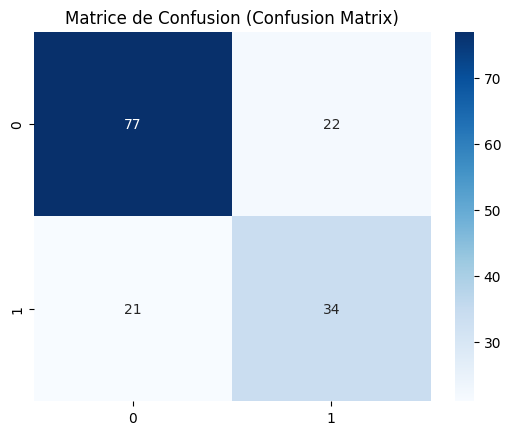

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel() # On extrait les 4 valeurs magiques

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion (Confusion Matrix)')
plt.show()

# **Metrics**

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Justesse (Accuracy) : {accuracy_score(y_test, y_pred):.2f}")
print(f"Précision (Precision) : {precision_score(y_test, y_pred):.2f}")
print(f"Rappel (Recall) : {recall_score(y_test, y_pred):.2f}")
print(f"Score F1 (F1-Score) : {f1_score(y_test, y_pred):.2f}")

Justesse (Accuracy) : 0.72
Précision (Precision) : 0.61
Rappel (Recall) : 0.62
Score F1 (F1-Score) : 0.61


# **ROC Curve & AUC**

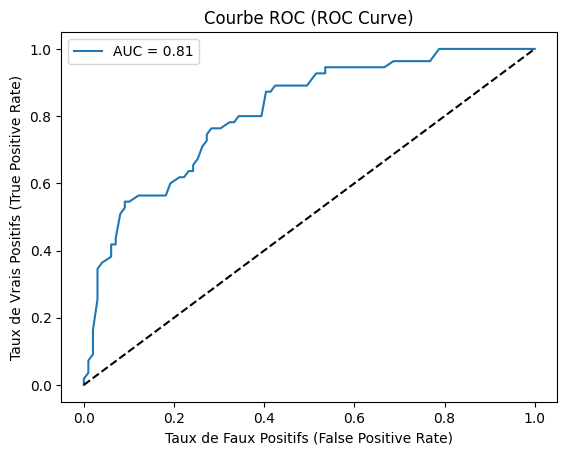

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # Ligne de chance
plt.xlabel('Taux de Faux Positifs (False Positive Rate)')
plt.ylabel('Taux de Vrais Positifs (True Positive Rate)')
plt.title('Courbe ROC (ROC Curve)')
plt.legend()
plt.show()

# **Coefficient de Corrélation de Matthews (MCC)**
C'est la métrique ultime pour les datasets déséquilibrés.

In [51]:
from sklearn.metrics import matthews_corrcoef
print(f"MCC Score : {matthews_corrcoef(y_test, y_pred):.2f}")

MCC Score : 0.39
